In [18]:
import polars as pl 
from pathlib import Path
from yaml import safe_load
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
import seaborn as sns 
import numpy as np
import math

sns.set_style('whitegrid')
from tqdm import tqdm
from matplotlib import gridspec

In [2]:
res_path = Path(
    "/projectnb/vkolagrp/projects/adrd_foundation_model/results/training_curve"
)

cols_to_read = ["ID", "ground_truth", "prediction"]#, "generated_text"]

In [3]:
def load_data(res_path, include_model="SFT"):
    
    ignored_files = []
    dfs = []
    skipped = set()
    
    for fpath in tqdm(res_path.rglob("*.parquet"), desc="Loading parquet files"):
        
        if include_model not in str(fpath):
            ignored_files.append(fpath)
            continue
        
        config_path = fpath.parent / 'config.yml'
        with config_path.open() as config_file:
            config = safe_load(config_file)
            
        df = pl.read_parquet(fpath, columns=cols_to_read).with_columns(
                pl.lit(fpath.parent.parent.parent.name).alias("benchmark"),
                pl.lit(fpath.parent.parent.parent.parent.name).alias("cohort"),
                (pl.col("ground_truth") == pl.col("prediction"))
                .cast(pl.Int8)
                .alias("correct"),
                pl.lit(config['training_steps']).alias('training_steps'),
                pl.lit(config['run_readable_name']).alias('model'),
                # pl.col("generated_text")
            )

        dfs.append(df)
    
    print(f"Ignored: {len(ignored_files)} files")
    print(f"Skipped: {skipped} files")
    return pl.concat(dfs)

In [4]:
# Load data for SFT (ignore SCE)
print("Loading SFT data...")
df_sft_all = load_data(res_path, include_model="NACC-3B-OS-SFT-ES")
print(len(df_sft_all))
df_sft = df_sft_all.filter(pl.col('benchmark').is_in(['test_mci','test_np_mixed','test_np', "test_ftld"]).not_())
print(len(df_sft))
print()

# Load data for SCE (ignore SFT)
print("Loading SCE data...")
df_sce_all = load_data(res_path, include_model="NACC-3B-OS-SCE")
print(len(df_sce_all))
df_sce = df_sce_all.filter(pl.col('benchmark').is_in(['test_mci','test_np_mixed','test_np', 'test_ftld']).not_())
print(len(df_sce))

# # Combine all data for baseline calculation
# df_all = pl.concat([df_sft, df_sce])

Loading SFT data...


Loading parquet files: 0it [00:00, ?it/s]

Loading parquet files: 1065it [00:03, 289.21it/s]


Ignored: 894 files
Skipped: set() files
3343905
3314790

Loading SCE data...


Loading parquet files: 1065it [00:05, 195.58it/s]

Ignored: 708 files
Skipped: set() files
7071660
6261270


In [5]:
df_sft.sample(5)

ID,ground_truth,prediction,benchmark,cohort,correct,training_steps,model
str,str,str,str,str,i8,i32,str
"""NACC497905""","""C""","""C""","""test_cog""","""nacc_test_updated""",1,240,"""NACC-3B-OS-SFT-ES-0240"""
"""NACC692858""","""C""","""C""","""test_cog""","""nacc_test_updated""",1,0,"""Qwen2.5-7B-Instruct"""
"""NACC325728""","""B""","""B""","""test_cog""","""nacc_test_updated""",1,360,"""NACC-3B-OS-SFT-ES-0360"""
"""NACC704322""","""H""","""H""","""test_etpr""","""nacc_test_updated""",1,420,"""NACC-3B-OS-SFT-ES-0420"""
"""6429""","""B""","""A""","""test_cog""","""adni_test""",0,240,"""NACC-3B-OS-SFT-ES-0240"""


In [6]:
n_boot = 1000

def bootstrap_micro_mean(df: pl.DataFrame, model_name: str, n_boot: int = 1000):
    # Filter to model at the sample (row) level
    df_m = df.filter(pl.col("model") == model_name)

    # Point estimate (micro-average across all samples)
    point = df_m.select(pl.col("correct").mean()).item()

    # Bootstrap by resampling samples (rows), then recomputing micro mean
    bs = np.array([
        df_m.sample(fraction=1.0, with_replacement=True)
            .select(pl.col("correct").mean()).item()
        for _ in range(n_boot)
    ])

    return point, bs.mean(), np.quantile(bs, 0.025), np.quantile(bs, 0.975)

def bootstrap_micro_mean_fast(df: pl.DataFrame, model_name: str, n_boot: int = 1000, seed: int = 0):
    df_m = df.filter(pl.col("model") == model_name).select("correct")
    y = df_m["correct"].to_numpy()  # 0/1 array
    n = y.size

    point = y.mean()

    rng = np.random.default_rng(seed)
    # sample indices: shape (n_boot, n)
    idx = rng.integers(0, n, size=(n_boot, n), endpoint=False)
    bs = y[idx].mean(axis=1)

    return point, bs.mean(), np.quantile(bs, 0.025), np.quantile(bs, 0.975)

def bootstrap_micro_mean_by_id(df: pl.DataFrame, model_name: str, id_col: str = "ID", n_boot: int = 1000, seed: int = 42):
    df_m = df.filter(pl.col("model") == model_name)

    # one row per ID: average over its 5 trials
    id_level = df_m.group_by(id_col).agg(pl.col("correct").mean().alias("id_acc"))

    y = id_level["id_acc"].to_numpy()
    n = y.size

    point = y.mean()

    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_boot, n))
    bs = y[idx].mean(axis=1)

    return point, bs.mean(), np.quantile(bs, 0.025), np.quantile(bs, 0.975)

def bootstrap_macro_cell_mean(df: pl.DataFrame, model_name: str, n_boot: int = 1000):
    """
    Sample-level bootstrap, but the metric is still the macro-average across (cohort, benchmark) cells:
      - resample rows
      - recompute per-cell accuracies
      - take mean of cell accuracies
    """
    df_m = df.filter(pl.col("model") == model_name)

    # Point estimate (macro-average across cells, computed on original data)
    base = (
        df_m.group_by("cohort", "benchmark")
            .agg(pl.col("correct").mean().alias("accuracy"))
    )
    point = base.select(pl.col("accuracy").mean()).item()

    bs = np.array([
        (
            df_m.sample(fraction=1.0, with_replacement=True)
                .group_by("cohort", "benchmark")
                .agg(pl.col("correct").mean().alias("accuracy"))
                .select(pl.col("accuracy").mean())
                .item()
        )
        for _ in range(n_boot)
    ])

    return point, bs.mean(), np.quantile(bs, 0.025), np.quantile(bs, 0.975)

def bootstrap_macro_cell_mean_cluster_id(
    df: pl.DataFrame,
    model_name: str,
    id_col: str = "ID",
    n_boot: int = 1000,
    seed: int | None = None,
):
    df_m = df.filter(pl.col("model") == model_name)

    # Collapse repeated trials -> one row per (cell, id)
    id_level = (
        df_m.group_by(["cohort", "benchmark", id_col])
            .agg(pl.col("correct").mean().alias("id_acc"))
    )

    # Point estimate: for each cell, mean over IDs; then macro over cells
    cell_base = (
        id_level.group_by(["cohort", "benchmark"])
                .agg(pl.col("id_acc").mean().alias("cell_acc"))
    )
    point = cell_base.select(pl.col("cell_acc").mean()).item()

    # Prepare arrays for fast bootstrap
    # Map each (cohort, benchmark) cell to an integer
    cells = cell_base.select(["cohort", "benchmark"]).with_row_index("cell_id")
    id_level2 = id_level.join(cells, on=["cohort", "benchmark"], how="inner")

    cell_id = id_level2["cell_id"].to_numpy()
    id_acc = id_level2["id_acc"].to_numpy()

    C = int(cells.height)

    # Group id_acc values by cell once
    # We'll store per-cell arrays of id_acc
    per_cell = [id_acc[cell_id == c] for c in range(C)]

    rng = np.random.default_rng(seed)
    bs = np.empty(n_boot, dtype=float)

    for b in range(n_boot):
        cell_means = np.empty(C, dtype=float)
        for c in range(C):
            a = per_cell[c]
            m = a.size
            # resample IDs (not trials) within cell
            idx = rng.integers(0, m, size=m)
            cell_means[c] = a[idx].mean()
        bs[b] = cell_means.mean()

    return point, bs.mean(), np.quantile(bs, 0.025), np.quantile(bs, 0.975)

# ---- Pick ONE of the two approaches above ----
# A) Micro-average accuracy (overall accuracy across samples)
# boot_fn = bootstrap_micro_mean_by_id

# B) Macro-average across (cohort, benchmark) but with sample-level bootstrap
boot_fn = bootstrap_macro_cell_mean_cluster_id

# ---- SFT ----
q3b_mean_sft, q3b_bs_mean_sft, q3b_low_sft, q3b_high_sft = boot_fn(df_sft, "Qwen2.5-3B-Instruct", n_boot=n_boot, id_col="ID")
q7b_mean_sft, q7b_bs_mean_sft, q7b_low_sft, q7b_high_sft = boot_fn(df_sft, "Qwen2.5-7B-Instruct", n_boot=n_boot, id_col="ID")

# ---- SCE ----
q3b_mean_sce, q3b_bs_mean_sce, q3b_low_sce, q3b_high_sce = boot_fn(df_sce, "Qwen2.5-3B-Instruct", n_boot=n_boot, id_col="ID")
q7b_mean_sce, q7b_bs_mean_sce, q7b_low_sce, q7b_high_sce = boot_fn(df_sce, "Qwen2.5-7B-Instruct", n_boot=n_boot, id_col="ID")

In [7]:
q3b_mean_sft, q3b_bs_mean_sft, q3b_low_sft, q3b_high_sft

(0.5186734115116746,
 0.5189299274953698,
 0.5088902657058388,
 0.5280017930819443)

In [8]:
def macro_ci_over_training_steps(
    df: pl.DataFrame,
    model_pattern: str = "NACC",
    id_col: str = "ID",
    n_boot: int = 1000,
    seed: int = 0,
):
    # Filter model(s) and add internal/external label
    d = (
        df.filter(pl.col("model").str.contains(model_pattern))
          .with_columns(
              pl.when(pl.col("cohort") == "nacc_test_updated")
                .then(pl.lit("Internal validation\n(NACC)"))
                .otherwise(pl.lit("External validation\n(All other cohorts)"))
                .alias("in_distribution")
          )
    )

    # Collapse repeated trials -> one row per (step, cell, id)
    # id_acc = mean(correct) across the 5 trials for that ID
    id_level = (
        d.group_by(["training_steps", "in_distribution", "cohort", "benchmark", id_col])
         .agg(pl.col("correct").mean().alias("id_acc"))
    )

    # Point estimate per step & group:
    # cell_acc = mean(id_acc) over IDs within cell, then macro over cells
    cell_level = (
        id_level.group_by(["training_steps", "in_distribution", "cohort", "benchmark"])
                .agg(pl.col("id_acc").mean().alias("cell_acc"))
    )
    point_df = (
        cell_level.group_by(["training_steps", "in_distribution"])
                 .agg(pl.col("cell_acc").mean().alias("point"))
    )

    # Bootstrap CIs
    rng = np.random.default_rng(seed)
    out_rows = []

    # Iterate over step × group, bootstrap within that slice
    # (Usually steps are not huge, so a Python loop here is fine.)
    steps_groups = (
        id_level.select(["training_steps", "in_distribution"])
                .unique()
                .sort(["training_steps", "in_distribution"])
                .iter_rows()
    )

    for step, grp in steps_groups:
        slice_df = id_level.filter(
            (pl.col("training_steps") == step) & (pl.col("in_distribution") == grp)
        )

        # Map each (cohort, benchmark) cell to an int
        cells = (
            slice_df.select(["cohort", "benchmark"])
                    .unique()
                    .with_row_index("cell_id")
        )
        s2 = slice_df.join(cells, on=["cohort", "benchmark"], how="inner")

        cell_id = s2["cell_id"].to_numpy()
        id_acc = s2["id_acc"].to_numpy()

        C = int(cells.height)

        # list of arrays: id_acc values for IDs in each cell
        per_cell = [id_acc[cell_id == c] for c in range(C)]

        # point estimate for this (step, grp)
        # (macro mean over cells of mean id_acc)
        cell_means = np.array([a.mean() for a in per_cell], dtype=float)
        point = float(cell_means.mean())

        bs = np.empty(n_boot, dtype=float)
        for b in range(n_boot):
            boot_cell_means = np.empty(C, dtype=float)
            for c in range(C):
                a = per_cell[c]
                m = a.size
                idx = rng.integers(0, m, size=m)   # resample IDs with replacement
                boot_cell_means[c] = a[idx].mean()
            bs[b] = boot_cell_means.mean()        # macro over cells

        low = float(np.quantile(bs, 0.025))
        high = float(np.quantile(bs, 0.975))

        out_rows.append((step, grp, point, low, high))

    return pl.DataFrame(out_rows, schema=["training_steps", "in_distribution", "point", "low", "high"])

In [9]:
ci_sft = macro_ci_over_training_steps(df_sft, id_col="ID", n_boot=1000, seed=0)
ci_sce = macro_ci_over_training_steps(df_sce, id_col="ID", n_boot=1000, seed=0)

/scratch/ipykernel_3621083/1577423404.py:91: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  return pl.DataFrame(out_rows, schema=["training_steps", "in_distribution", "point", "low", "high"])


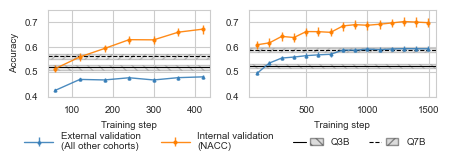

In [10]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerTuple

# Create figure with two subplots side by side
fig = plt.figure(figsize=(4.6, 1.5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.3, 1.5])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharey=ax1)

fontsize = 7
linewidth = 1
markersize = 2

markers = {
    'External validation\n(All other cohorts)': '^',
    'Internal validation\n(NACC)': 'o'
}
colors = {
    'Internal validation\n(NACC)': '#ff7f00',
    'External validation\n(All other cohorts)': '#377eb8'
}

plot_configs = [
    {
        "ax": ax1, "ci_pd": ci_sft.sort(["training_steps", "in_distribution"]).to_pandas(),
        "baselines": {"3B": (q3b_mean_sft, q3b_low_sft, q3b_high_sft), "7B": (q7b_mean_sft, q7b_low_sft, q7b_high_sft)},
        "ylabel": "Accuracy", "title": "SFT",
    },
    {
        "ax": ax2, "ci_pd": ci_sce.sort(["training_steps", "in_distribution"]).to_pandas(),
        "baselines": {"3B": (q3b_mean_sce, q3b_low_sce, q3b_high_sce), "7B": (q7b_mean_sce, q7b_low_sce, q7b_high_sce)},
        "ylabel": "", "title": "SCE",
    },
]

hatch_styles = {"3B": "\\\\\\", "7B": "///"}
linestyles = {"3B": "-", "7B": "--"}

# Build combined (line + patch) legend handles for baselines
baseline_handles = {}
for size in ["3B", "7B"]:
    line = mlines.Line2D([], [], color="black", linewidth=0.8, linestyle=linestyles[size])
    patch = mpatches.Patch(facecolor="darkgray", edgecolor="black", hatch=hatch_styles[size], alpha=0.4)
    baseline_handles[size] = (line, patch)

for cfg in plot_configs:
    ax = cfg["ax"]

    for label, group_df in cfg["ci_pd"].groupby("in_distribution", sort=False):
        x = group_df["training_steps"].to_numpy()
        y = group_df["point"].to_numpy()
        yerr = np.vstack([y - group_df["low"].to_numpy(), group_df["high"].to_numpy() - y])
        ax.errorbar(x, y, yerr=yerr, linewidth=linewidth, marker=markers[label],
                    markersize=markersize, alpha=0.9, color=colors.get(label), label=label)

    for size, (mean, low, high) in cfg["baselines"].items():
        ax.axhline(y=mean, color="black", linewidth=0.8, linestyle=linestyles[size])
        ax.axhspan(low, high, alpha=0.2, hatch=hatch_styles[size], edgecolor="black", facecolor="darkgray", zorder=0)

    # ax.set_title(cfg["title"], fontsize=fontsize + 1, fontweight="bold")
    ax.set_ylabel(cfg["ylabel"], fontsize=fontsize)
    ax.set_xlabel("Training step", fontsize=fontsize)
    ax.tick_params(axis="both", labelsize=fontsize)

ax1.set_ylim(0.4, 0.75)

# Combine errorbar handles + baseline (line + patch) handles
line_handles, line_labels = ax1.get_legend_handles_labels()
all_handles = line_handles + [baseline_handles["3B"], baseline_handles["7B"]]
all_labels = line_labels + ["Q3B", "Q7B"]

for ax in [ax1, ax2]:
    if ax.get_legend():
        ax.get_legend().remove()

fig.legend(
    all_handles, all_labels,
    loc="lower center", ncol=4, fontsize=fontsize,
    bbox_to_anchor=(0.5, -0.1), frameon=False,
    handler_map={tuple: HandlerTuple(ndivide=None, pad=0.5)},
    handlelength=3,  # increase this (default is 2)
)

plt.tight_layout()
fig.savefig('../figures/fig2_test_perf_over_training_id_bootstrap.pdf', dpi=200, format="pdf", bbox_inches="tight")
# plt.show()

# Ablated models

In [11]:
# Load data for SFT (ignore SCE)
print("Loading NACC-3B data...")
df_nacc_3b = load_data(res_path, include_model="/NACC-3B/")
df_nacc_3b = df_nacc_3b.filter(pl.col('benchmark').is_in(['test_mci','test_np_mixed','test_np', "test_ftld"]).not_())

# Do the same for NACC-3B-SCE
print("Loading NACC-3B-SCE data...")
df_nacc_3b_sce = load_data(res_path, include_model="/NACC-3B-SCE/")
df_nacc_3b_sce = df_nacc_3b_sce.filter(pl.col('benchmark').is_in(['test_mci','test_np_mixed','test_np', "test_ftld"]).not_())

# Do the same for NACC-3B-OS
print("Loading NACC-3B-OS data...")
df_nacc_3b_os = load_data(res_path, include_model="/NACC-3B-OS/")
df_nacc_3b_os = df_nacc_3b_os.filter(pl.col('benchmark').is_in(['test_mci','test_np_mixed','test_np', "test_ftld"]).not_())


Loading NACC-3B data...


Loading parquet files: 1065it [00:03, 281.65it/s]


Ignored: 957 files
Skipped: set() files
Loading NACC-3B-SCE data...


Loading parquet files: 1065it [00:03, 335.78it/s]


Ignored: 957 files
Skipped: set() files
Loading NACC-3B-OS data...


Loading parquet files: 1065it [00:05, 208.46it/s]

Ignored: 921 files
Skipped: set() files


In [12]:
ci_nacc_3b = macro_ci_over_training_steps(df_nacc_3b, id_col="ID", n_boot=1000, seed=0)
ci_nacc_3b_sce = macro_ci_over_training_steps(df_nacc_3b_sce, id_col="ID", n_boot=1000, seed=0)
ci_nacc_3b_os = macro_ci_over_training_steps(df_nacc_3b_os, id_col="ID", n_boot=1000, seed=0)

/scratch/ipykernel_3621083/1577423404.py:91: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  return pl.DataFrame(out_rows, schema=["training_steps", "in_distribution", "point", "low", "high"])


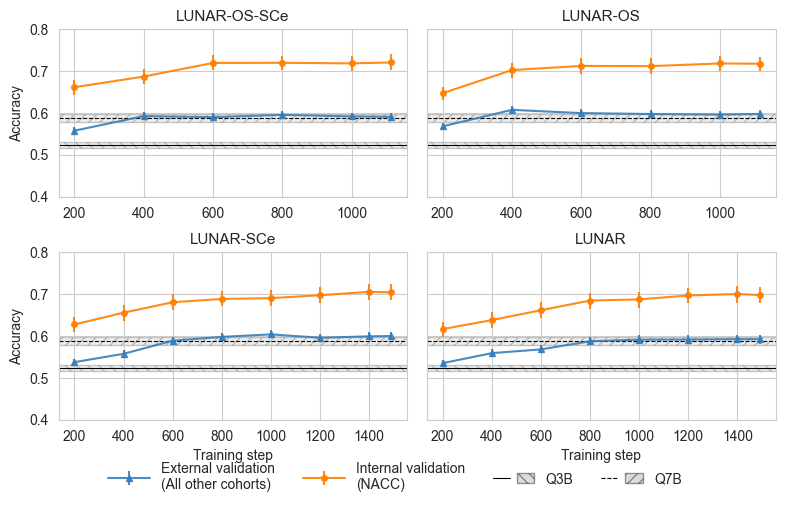

In [13]:
fontsize = 10
linewidth = 1.5
markersize = 4

fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharey=True)

panel_titles = ["LUNAR-OS-SCe", "LUNAR-OS", "LUNAR-SCe", "LUNAR"]
ci_list = [ci_nacc_3b, ci_nacc_3b_sce, ci_nacc_3b_os, ci_sce]

markers = {
    'External validation\n(All other cohorts)': '^',
    'Internal validation\n(NACC)': 'o'
}
colors = {
    'Internal validation\n(NACC)': '#ff7f00',
    'External validation\n(All other cohorts)': '#377eb8'
}

hatch_styles = {"3B": "\\\\\\", "7B": "///"}
linestyles = {"3B": "-", "7B": "--"}

baselines = {
    "3B": (q3b_mean_sce, q3b_low_sce, q3b_high_sce),
    "7B": (q7b_mean_sce, q7b_low_sce, q7b_high_sce),
}

axes_flat = axes.flatten()

def select_every_200_and_last(df, step_col="training_steps"):
    if df.empty:
        return df
    step_vals = df[step_col].unique()
    step_vals_sorted = np.sort(step_vals)
    every_200 = set(step_vals_sorted[step_vals_sorted % 200 == 0])
    every_200.add(step_vals_sorted[-1])
    selection = df[df[step_col].isin(list(every_200))].copy()
    return selection.sort_values(step_col)

for i, ax in enumerate(axes_flat):
    ci_df = ci_list[i].to_pandas()

    if "in_distribution" in ci_df.columns:
        for label, group_df in ci_df.groupby("in_distribution"):
            group_df_sub = select_every_200_and_last(group_df, step_col="training_steps")
            x = group_df_sub["training_steps"].to_numpy()
            y = group_df_sub["point"].to_numpy()
            yerr = np.vstack([y - group_df_sub["low"].to_numpy(), group_df_sub["high"].to_numpy() - y])
            ax.errorbar(x, y, yerr=yerr, linewidth=linewidth, marker=markers.get(label, "x"),
                        markersize=markersize, alpha=0.9, color=colors.get(label),
                        label=label if i == 0 else None)

    for size, (mean, low, high) in baselines.items():
        ax.axhline(y=mean, color="black", linewidth=0.8, linestyle=linestyles[size])
        ax.axhspan(low, high, alpha=0.2, hatch=hatch_styles[size], edgecolor="black", facecolor="darkgray", zorder=0)

    ax.set_title(panel_titles[i], fontsize=fontsize + 1)
    ax.set_ylabel("Accuracy" if i % 2 == 0 else "", fontsize=fontsize)
    ax.set_xlabel("Training step" if i in [2, 3] else "", fontsize=fontsize)
    ax.tick_params(axis="both", labelsize=fontsize)

# Build combined (line + patch) legend handles for baselines
baseline_handles = {
    size: (
        mlines.Line2D([], [], color="black", linewidth=0.8, linestyle=linestyles[size]),
        mpatches.Patch(facecolor="darkgray", edgecolor="black", hatch=hatch_styles[size], alpha=0.4),
    )
    for size in ["3B", "7B"]
}

line_handles, line_labels = axes_flat[0].get_legend_handles_labels()
all_handles = line_handles + [baseline_handles["3B"], baseline_handles["7B"]]
all_labels = line_labels + ["Q3B", "Q7B"]

for ax in axes_flat:
    ax.set_ylim(0.4, 0.8)
    if ax.get_legend():
        ax.get_legend().remove()

fig.legend(
    all_handles, all_labels,
    loc="lower center", ncol=4, fontsize=fontsize,
    bbox_to_anchor=(0.5, -0.02), frameon=False,
    handler_map={tuple: HandlerTuple(ndivide=None, pad=0.5)},
    handlelength=3,
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
fig.savefig('../figures/sup_test_perf_over_training_id_bootstrap_ablations.pdf', dpi=200, format="pdf", bbox_inches="tight")
# plt.show()

# Per task plots

In [14]:
# Prepare SCE data with internal/external labels
df_sce_all = df_sce_all.filter(pl.col('benchmark').is_in(['test_mci','test_ftld']).not_())
acc_sce_all = df_sce_all.filter(pl.col('model').str.contains('NACC')).group_by('training_steps','cohort','benchmark').agg(
    pl.col('correct').mean()
).sort('training_steps')

In [15]:
df_sce_all.head()

ID,ground_truth,prediction,benchmark,cohort,correct,training_steps,model
str,str,str,str,str,i8,i32,str
"""sub-CLB00196""","""A""","""C""","""test_cog""","""brainlat_test""",0,0,"""Qwen2.5-7B-Instruct"""
"""sub-CLB00196""","""A""","""A""","""test_cog""","""brainlat_test""",1,0,"""Qwen2.5-7B-Instruct"""
"""sub-CLB00196""","""A""","""A""","""test_cog""","""brainlat_test""",1,0,"""Qwen2.5-7B-Instruct"""
"""sub-CLB00196""","""A""","""C""","""test_cog""","""brainlat_test""",0,0,"""Qwen2.5-7B-Instruct"""
"""sub-CLB00196""","""A""","""A""","""test_cog""","""brainlat_test""",1,0,"""Qwen2.5-7B-Instruct"""


In [16]:
n_boot = 1000
base_values_sce = {}  # {benchmark: {"3B": {...}, "7B": {...}}}

for model_size, model_name in [("3B", "Qwen2.5-3B-Instruct"),
                               ("7B", "Qwen2.5-7B-Instruct")]:

    # Get unique benchmarks for this model
    benchmarks = (
        df_sce_all
        .filter(pl.col("model") == model_name)
        .select(pl.col("benchmark").unique())
        .to_series()
        .to_list()
    )

    for bench in benchmarks:
        # Slice to model + benchmark
        df_slice = df_sce_all.filter(
            (pl.col("model") == model_name) &
            (pl.col("benchmark") == bench)
        )

        mean, bs_mean, low, high = bootstrap_macro_cell_mean_cluster_id(
            df_slice, 
            model_name=model_name,   # function still expects it
            n_boot=n_boot,
            seed=0
        )

        if bench not in base_values_sce:
            base_values_sce[bench] = {}

        base_values_sce[bench][model_size] = {
            "mean": mean,
            "bs_mean": bs_mean,
            "low": low,
            "high": high,
        }

/scratch/ipykernel_3621083/1577423404.py:91: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  return pl.DataFrame(out_rows, schema=["training_steps", "in_distribution", "point", "low", "high"])
/scratch/ipykernel_3621083/1577423404.py:91: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  return pl.DataFrame(out_rows, schema=["training_steps", "in_distribution", "point", "low", "high"])
/scratch/ipykernel_3621083/1577423404.py:91: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  return pl.DataFrame(out_rows, schema=["training_steps", "in_distribution", "point", "low", "high"])
/scratch/ipykernel_3621083/1577423404.py:91: DataOrientationW

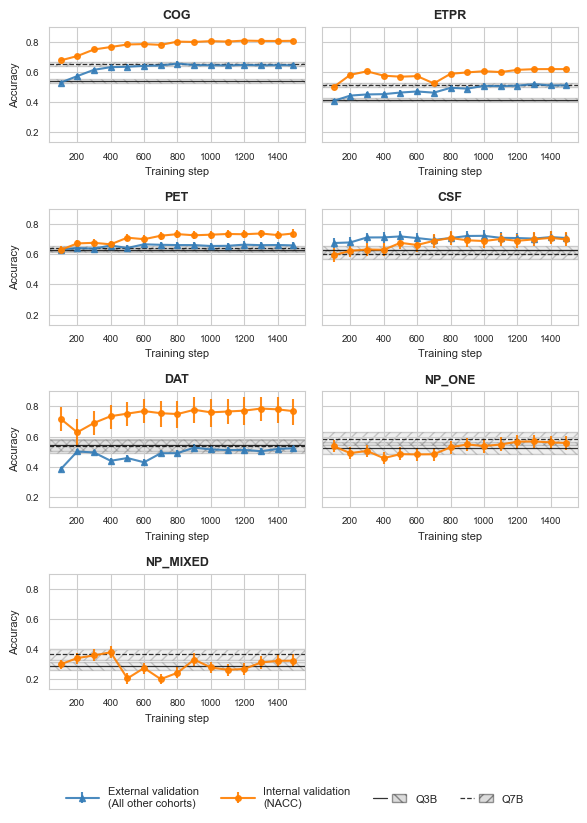

In [20]:
benchmark_label_map = {
    "test_cog": "COG",
    "test_etpr": "ETPR",
    "test_pet": "PET",
    "test_csf": "CSF",
    "test_dat": "DAT",
    "test_np_one": "NP_ONE",
    "test_np_mixed": "NP_MIXED"
}
benchmarks = list(benchmark_label_map.keys())
n_bench = len(benchmarks)
ncols = 2
nrows = math.ceil(n_bench / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6, 8), sharey=True)

fontsize = 8
linewidth = 1.5
markersize = 4

markers = {
    'External validation\n(All other cohorts)': '^',
    'Internal validation\n(NACC)': 'o'
}
colors = {
    'Internal validation\n(NACC)': '#ff7f00',
    'External validation\n(All other cohorts)': '#377eb8'
}
hatch_styles = {'3B': '\\\\\\', '7B': '///'}
linestyles = {'3B': '-', '7B': '--'}

for idx, benchmark in enumerate(benchmarks):
    row = idx // ncols
    col = idx % ncols
    ax = axes[row, col] if nrows > 1 else axes[col]

    base_sce = base_values_sce.get(benchmark, {})

    ci_bench = macro_ci_over_training_steps(
        df_sce_all.filter(pl.col("benchmark") == benchmark),
        model_pattern="NACC",
        id_col="ID",
        n_boot=1000,
        seed=0,
    ).sort(["training_steps", "in_distribution"])

    ci_bench_pd = ci_bench.to_pandas()

    if "in_distribution" in ci_bench_pd.columns:
        for label, group_df in ci_bench_pd.groupby('in_distribution'):
            x = group_df["training_steps"].to_numpy()
            y = group_df["point"].to_numpy()
            yerr = np.vstack([y - group_df["low"].to_numpy(), group_df["high"].to_numpy() - y])
            ax.errorbar(x, y, yerr=yerr, linewidth=linewidth, marker=markers.get(label, 'x'),
                        markersize=markersize, alpha=0.9, color=colors.get(label),
                        label=label if idx == 0 else None)

    for size in ["3B", "7B"]:
        cur = base_sce.get(size)
        if cur is not None:
            ax.axhline(y=cur["mean"], color='black', linewidth=0.9, linestyle=linestyles[size], alpha=0.8)
            ax.axhspan(cur["low"], cur["high"], alpha=0.18, facecolor='darkgray',
                       edgecolor='black', hatch=hatch_styles[size], zorder=0)

    ax.set_title(benchmark_label_map.get(benchmark, benchmark), fontsize=fontsize+1, fontweight='bold')
    ax.set_xlabel("Training step", fontsize=fontsize)
    ax.set_ylabel("Accuracy" if col == 0 else "", fontsize=fontsize)
    ax.tick_params(axis='x', labelsize=fontsize-1)
    ax.tick_params(axis='y', labelsize=fontsize-1)

# Clean up empty axes
total_axes = nrows * ncols
for idx2 in range(len(benchmarks), total_axes):
    ax = axes[idx2 // ncols, idx2 % ncols] if nrows > 1 else axes[idx2 % ncols]
    ax.axis('off')

# Build combined (line + patch) legend handles for baselines
baseline_handles = {
    size: (
        mlines.Line2D([], [], color="black", linewidth=0.9, linestyle=linestyles[size], alpha=0.8),
        mpatches.Patch(facecolor="darkgray", edgecolor="black", hatch=hatch_styles[size], alpha=0.4),
    )
    for size in ["3B", "7B"]
}

first_ax = axes[0, 0] if nrows > 1 else axes[0]
line_handles, line_labels = first_ax.get_legend_handles_labels()
all_handles = line_handles + [baseline_handles["3B"], baseline_handles["7B"]]
all_labels = line_labels + ["Q3B", "Q7B"]

axs = axes.flatten() if nrows > 1 else axes
for ax in axs:
    if ax.get_legend():
        ax.get_legend().remove()

fig.legend(
    all_handles, all_labels,
    loc='lower center', ncol=4, fontsize=fontsize,
    bbox_to_anchor=(0.5, -0.03), frameon=False,
    handler_map={tuple: HandlerTuple(ndivide=None, pad=0.5)},
    handlelength=3,
)

plt.tight_layout(rect=[0, 0.07, 1, 1])
fig.savefig('../figures/sup_test_perf_over_training_id_bootstrap_sep_benchmarks.pdf', dpi=200, format="pdf", bbox_inches="tight")
# plt.show()